In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [42]:
final_df = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/processed/final_df_clean.csv")
final_df["date"] = pd.to_datetime(final_df["date"])

final_df = final_df.sort_values(
    ["sku_id", "date"]
)

In [43]:
final_df   = final_df.rename(columns = {'week_ofear' : 'week_of_year'})

In [44]:
final_df = final_df.drop(columns=[col for col in final_df.columns if col.endswith('.1')])

In [45]:
print(final_df.columns[final_df.columns.duplicated()])

Index([], dtype='object')


In [46]:
final_df["target_7d"] = (
    final_df.groupby("sku_id")["units_sold"]
    .shift(-7)
)


In [47]:
final_df["lag_1_units"] = (
    final_df.groupby("sku_id")["units_sold"]
    .shift(1)
)

final_df["lag_7_units"] = (
    final_df.groupby("sku_id")["units_sold"]
    .shift(7)
)

final_df["lag_14_units"] = (
    final_df.groupby("sku_id")["units_sold"]
    .shift(14)
)

final_df["lag_21_units"] = (
    final_df.groupby("sku_id")["units_sold"]
    .shift(21)
)

final_df["lag_30_units"] = (
    final_df.groupby("sku_id")["units_sold"]
    .shift(30)
)

In [48]:
final_df["rolling_mean_7"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

final_df["rolling_mean_14"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

final_df["rolling_mean_30"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

final_df["rolling_mean_60"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(60).mean()
    )
)

In [49]:
final_df["rolling_std_7"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)


final_df["rolling_std_30"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(30).std()
    )
)

final_df["rolling_std_60"] = (
    final_df.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(60).std()
    )
)

In [50]:
category_encoder = LabelEncoder()

final_df["category_encoded"] = (
    category_encoder.fit_transform(
        final_df["category"]
    )
)

subcategory_encoder = LabelEncoder()

final_df["subcategory_encoded"] = (
    subcategory_encoder.fit_transform(
        final_df["sub_category"]
    )
)

In [51]:
model_df = final_df.dropna().copy()

print(model_df.shape)

(11960, 55)


In [52]:
feature_cols = [

    "selling_price",

    "promo_flag",
    "discount_pct",

    "month",
    "week_of_year",
    "day_of_week",

    "is_weekend",
    "is_festival_month",
    "is_payday_period",

    "holiday_flag",

    "weather_index",
    "campaign_intensity",

    "traffic_index",

    "competitor_price_index",
    "competitor_stockout_flag",

    "bundle_offer_flag",

    "stock_visibility_score",
    "rating_score",
    "review_volume",

    "product_visibility_rank",

    "category_encoded",
    "subcategory_encoded",

    "lag_1_units",
    "lag_7_units",
    "lag_14_units",
    "lag_21_units",
    "lag_30_units",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_mean_60",

    "rolling_std_7",
    "rolling_std_30",
    "rolling_std_60"
]


In [53]:
X = model_df[feature_cols]

y = model_df["target_7d"]

In [54]:
cutoff_date = model_df["date"].quantile(0.80)

train = model_df[
    model_df["date"] <= cutoff_date
]

test = model_df[
    model_df["date"] > cutoff_date
]

In [55]:
X_train = train[feature_cols]
y_train = train["target_7d"]

X_test = test[feature_cols]
y_test = test["target_7d"]

In [56]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
rf_pred = rf.predict(X_test)

In [58]:
mae = mean_absolute_error(
    y_test,
    rf_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

r2 = r2_score(
    y_test,
    rf_pred
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 5.66
RMSE : 6.92
R²   : 0.1714


In [59]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
30,rolling_mean_60,0.251274
29,rolling_mean_30,0.139298
13,competitor_price_index,0.098598
4,week_of_year,0.068058
12,traffic_index,0.049311
10,weather_index,0.045434
28,rolling_mean_14,0.024982
31,rolling_std_7,0.023322
27,rolling_mean_7,0.019757
5,day_of_week,0.019727


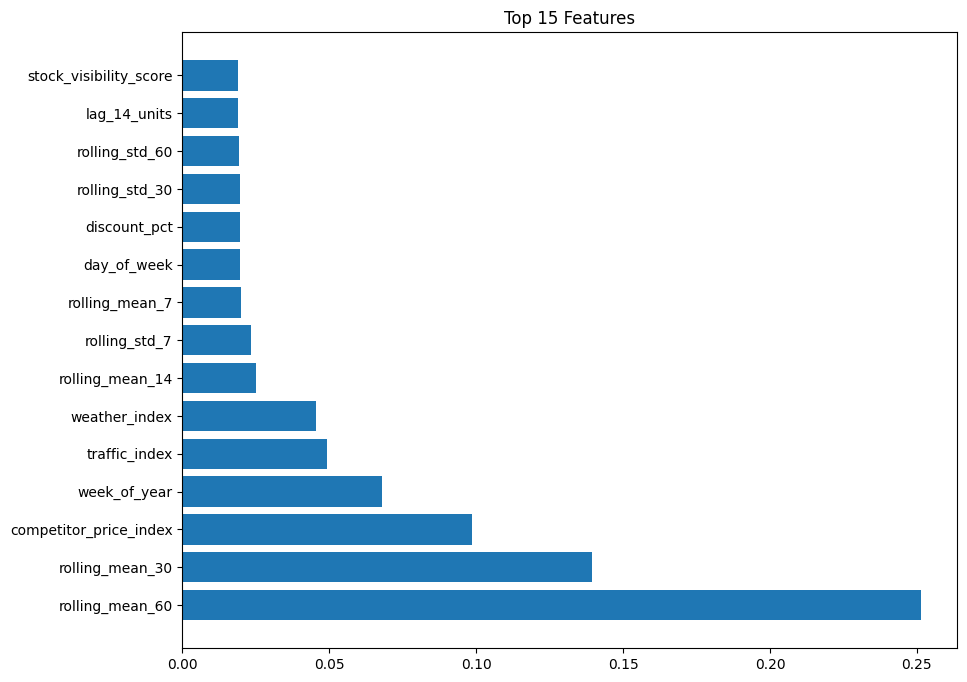

In [60]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["feature"][:15],
    importance["importance"][:15]
)

plt.title("Top 15 Features")

plt.show()